In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
INFER_ROOT = Path("../inference").expanduser().resolve()

ZS_MIOU   = INFER_ROOT / "clipseg_cloudsen12plus_zs" / "miou_clipseg_cloudsen12plus_zs_eval.csv"
LORA_MIOU = INFER_ROOT / "clipseg_cloudsen12plus_lora" / "miou_clipseg_cloudsen12plus_lora_eval.csv"
FFT_MIOU  = INFER_ROOT / "clipseg_cloudsen12plus_fft" / "miou_clipseg_cloudsen12plus_fft_eval.csv"

LORA_LOW  = INFER_ROOT / "clipseg_cloudsen12plus_lora_low_data" / "lora_low_data_ladder.csv"
FFT_LOW   = INFER_ROOT / "clipseg_cloudsen12plus_fft_low_data" / "fft_low_data_ladder.csv"

for p in [ZS_MIOU, LORA_MIOU, FFT_MIOU, LORA_LOW, FFT_LOW]:
    print(("✅" if p.exists() else "❌"), p)


✅ /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv
✅ /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora/miou_clipseg_cloudsen12plus_lora_eval.csv
✅ /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_fft/miou_clipseg_cloudsen12plus_fft_eval.csv
✅ /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_lora_low_data/lora_low_data_ladder.csv
✅ /Users/harshithkethavath/Library/Mobile Documents/com~apple~CloudDocs/University of Georgia/Dr. Weiming Hu/2026_CloudPrompts/code/inference/clipseg_cloudsen12plus_f

In [3]:
def read_aggregate_row(miou_csv: Path) -> pd.Series:
    df = pd.read_csv(miou_csv)
    if "id" not in df.columns:
        raise ValueError(f"'id' column missing in {miou_csv}")
    agg = df[df["id"] == "__aggregate__"]
    if agg.empty:
        raise ValueError(f"No __aggregate__ row found in {miou_csv}")
    if len(agg) > 1:
        raise ValueError(f"Multiple __aggregate__ rows found in {miou_csv}")
    return agg.iloc[0]

zs_agg   = read_aggregate_row(ZS_MIOU)
lora_agg = read_aggregate_row(LORA_MIOU)
fft_agg  = read_aggregate_row(FFT_MIOU)

lora_low = pd.read_csv(LORA_LOW)
fft_low  = pd.read_csv(FFT_LOW)

print("ZS mIoU  :", float(zs_agg["miou"]))
print("LoRA mIoU:", float(lora_agg["miou"]))
print("FFT mIoU :", float(fft_agg["miou"]))
print("lora_low rows:", len(lora_low), " | fft_low rows:", len(fft_low))


ZS mIoU  : 0.2550400406013244
LoRA mIoU: 0.5991315104337002
FFT mIoU : 0.6572447410809639
lora_low rows: 6  | fft_low rows: 13


In [4]:
KEEP_PCTS = [0.1, 0.5, 1, 5, 10, 50]

def prep_low_df(df: pd.DataFrame, keep_pcts=KEEP_PCTS) -> pd.DataFrame:
    out = df.copy()
    out["pct_rounded"] = out["pct"].astype(float).round(3)
    out = out[out["pct_rounded"].isin([round(x, 3) for x in keep_pcts])].copy()
    out = out.sort_values("pct_rounded")
    return out

lora_low_k = prep_low_df(lora_low)
fft_low_k  = prep_low_df(fft_low)

lora_full_point = pd.DataFrame([{"pct": 100.0, "miou_mean": float(lora_agg["miou"]), "miou_std": np.nan}])
fft_full_point  = pd.DataFrame([{"pct": 100.0, "miou_mean": float(fft_agg["miou"]),  "miou_std": np.nan}])

lora_plot = pd.concat([lora_low_k[["pct","miou_mean","miou_std"]], lora_full_point], ignore_index=True).sort_values("pct")
fft_plot  = pd.concat([fft_low_k[["pct","miou_mean","miou_std"]],  fft_full_point],  ignore_index=True).sort_values("pct")

display(lora_plot)
display(fft_plot)


,pct,miou_mean,miou_std
0,0.1,0.269219,0.009396
1,0.5,0.262399,0.009344
2,1.0,0.301695,0.014967
3,5.0,0.434950,0.064952
4,10.0,0.482495,0.021771
5,50.0,0.564985,0.019513
6,100.0,0.599132,NaN


,pct,miou_mean,miou_std
0,0.1,0.270951,0.010473
1,0.5,0.304765,0.019837
2,1.0,0.350770,0.034354
3,5.0,0.526491,0.008548
4,10.0,0.571587,0.010149
5,50.0,0.639977,0.005174
6,100.0,0.657245,NaN


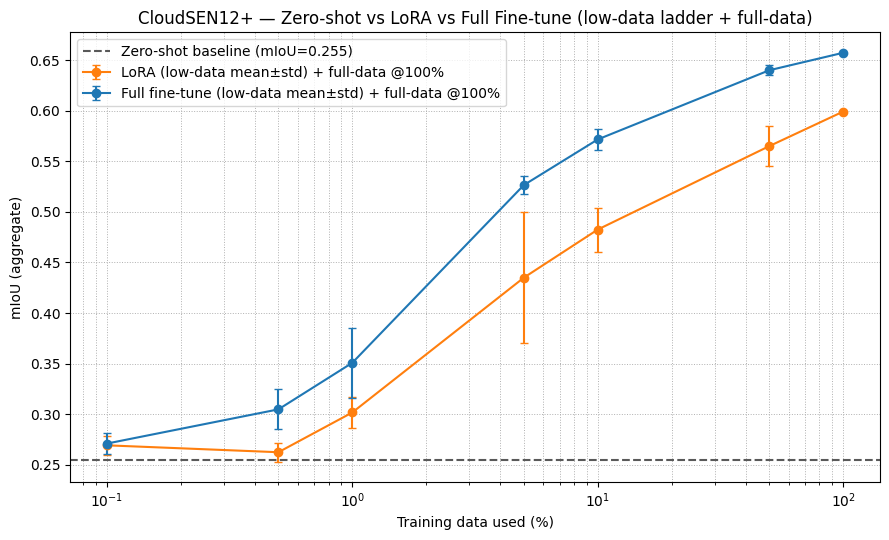

In [5]:
LORA_COLOR = "tab:orange"
FFT_COLOR  = "tab:blue"
ZS_COLOR   = "0.35"

plt.figure(figsize=(9, 5.5))

plt.errorbar(
    lora_plot["pct"], lora_plot["miou_mean"], yerr=lora_plot["miou_std"],
    fmt="o-", color=LORA_COLOR, capsize=3,
    label="LoRA (low-data mean±std) + full-data @100%"
)

plt.errorbar(
    fft_plot["pct"], fft_plot["miou_mean"], yerr=fft_plot["miou_std"],
    fmt="o-", color=FFT_COLOR, capsize=3,
    label="Full fine-tune (low-data mean±std) + full-data @100%"
)

zs_miou = float(zs_agg["miou"])
plt.axhline(zs_miou, linestyle="--", color=ZS_COLOR, label=f"Zero-shot baseline (mIoU={zs_miou:.3f})")

plt.xscale("log")
plt.xlabel("Training data used (%)")
plt.ylabel("mIoU (aggregate)")
plt.title("CloudSEN12+ — Zero-shot vs LoRA vs Full Fine-tune (low-data ladder + full-data)")

plt.grid(True, which="both", linestyle=":", linewidth=0.7)
plt.legend()
plt.tight_layout()
plt.show()


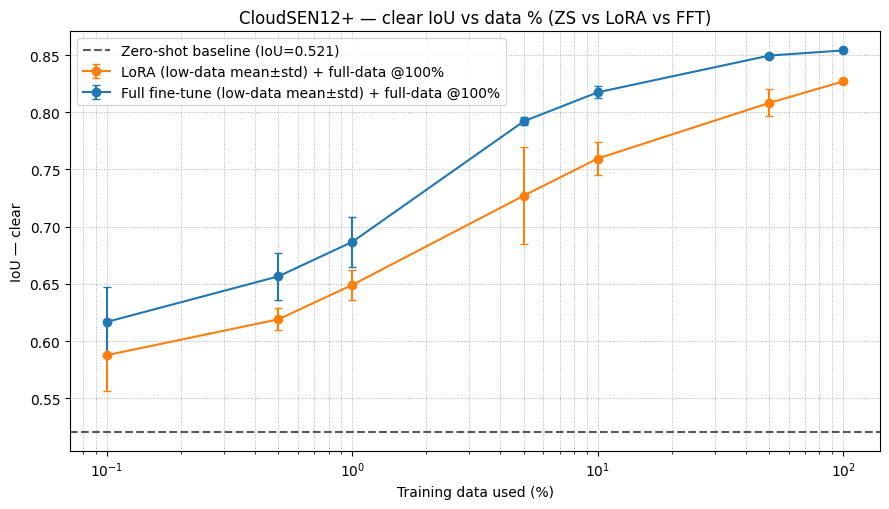

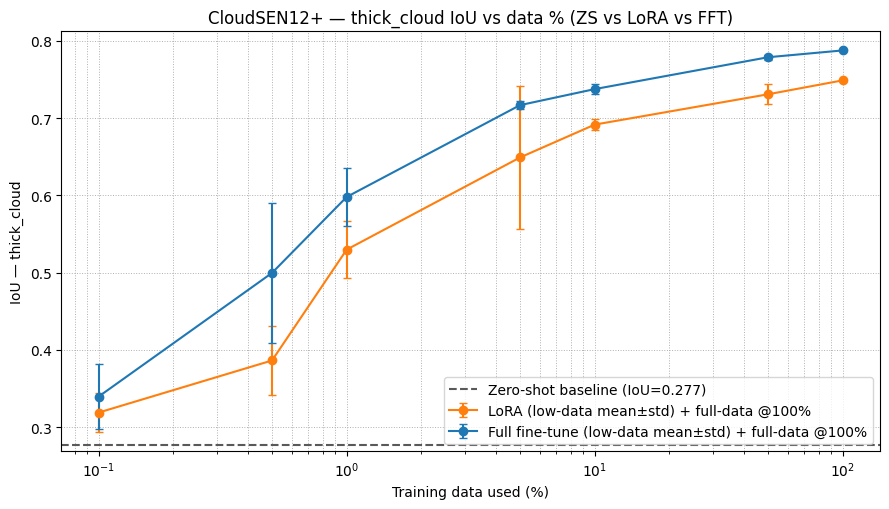

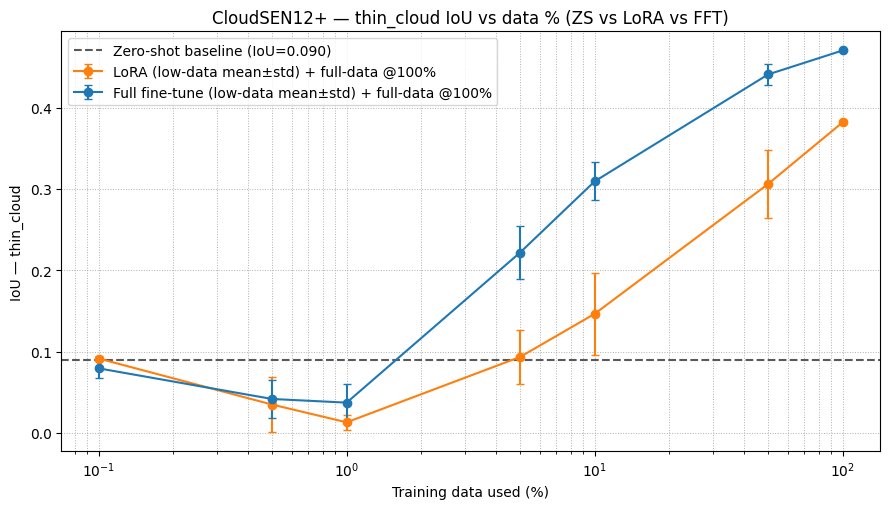

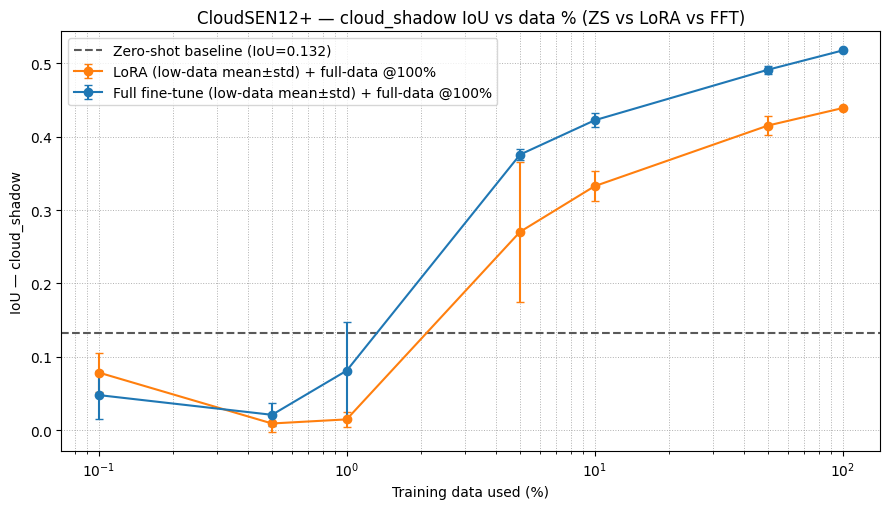

In [ ]:
CLASSES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]

def plot_class_iou_ladders(class_name: str):
    col_mean = f"iou_{class_name}_mean"
    col_std  = f"iou_{class_name}_std"

    lora_c = lora_low_k[["pct", col_mean, col_std]].rename(columns={col_mean:"mean", col_std:"std"}).copy()
    fft_c  = fft_low_k[["pct", col_mean, col_std]].rename(columns={col_mean:"mean", col_std:"std"}).copy()

    lora_full = pd.DataFrame([{"pct":100.0, "mean": float(lora_agg[f"iou_{class_name}"]), "std": np.nan}])
    fft_full  = pd.DataFrame([{"pct":100.0, "mean": float(fft_agg[f"iou_{class_name}"]),  "std": np.nan}])

    lora_c = pd.concat([lora_c, lora_full], ignore_index=True).sort_values("pct")
    fft_c  = pd.concat([fft_c,  fft_full],  ignore_index=True).sort_values("pct")
                                                                
    zs_val = float(zs_agg[f"iou_{class_name}"])

    plt.figure(figsize=(9, 5.2))
    plt.errorbar(lora_c["pct"], lora_c["mean"], yerr=lora_c["std"], fmt="o-", color=LORA_COLOR, capsize=3,
                 label="LoRA (low-data mean±std) + full-data @100%")
    plt.errorbar(fft_c["pct"],  fft_c["mean"],  yerr=fft_c["std"],  fmt="o-", color=FFT_COLOR,  capsize=3,
                 label="Full fine-tune (low-data mean±std) + full-data @100%")
    plt.axhline(zs_val, linestyle="--", color=ZS_COLOR, label=f"Zero-shot baseline (IoU={zs_val:.3f})")

    plt.xscale("log")
    plt.xlabel("Training data used (%)")
    plt.ylabel(f"IoU — {class_name}")
    plt.title(f"CloudSEN12+ — {class_name} IoU vs data % (ZS vs LoRA vs FFT)")
    plt.grid(True, which="both", linestyle=":", linewidth=0.7)
    plt.legend()
    plt.tight_layout()
    plt.show()

for c in CLASSES:
    plot_class_iou_ladders(c)
